In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Diwali Sales Data.csv',encoding='latin-1')

In [7]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [3]:
df['Marital_Status']=df['Marital_Status'].replace({0:"Unmarried",1:"married"})

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [9]:
df.shape

(11251, 15)

In [10]:
df.drop(['Status','unnamed1'],axis=1,inplace=True)


In [11]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0


In [12]:
df.shape

(11251, 13)

In [13]:
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [14]:
df.dropna(inplace=True)

In [15]:
df.isnull().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [16]:
df[['Age','Orders','Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610858
std,12.753866,1.114967,5222.355869
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


# EDA(exploratory data analysis)

## Gender

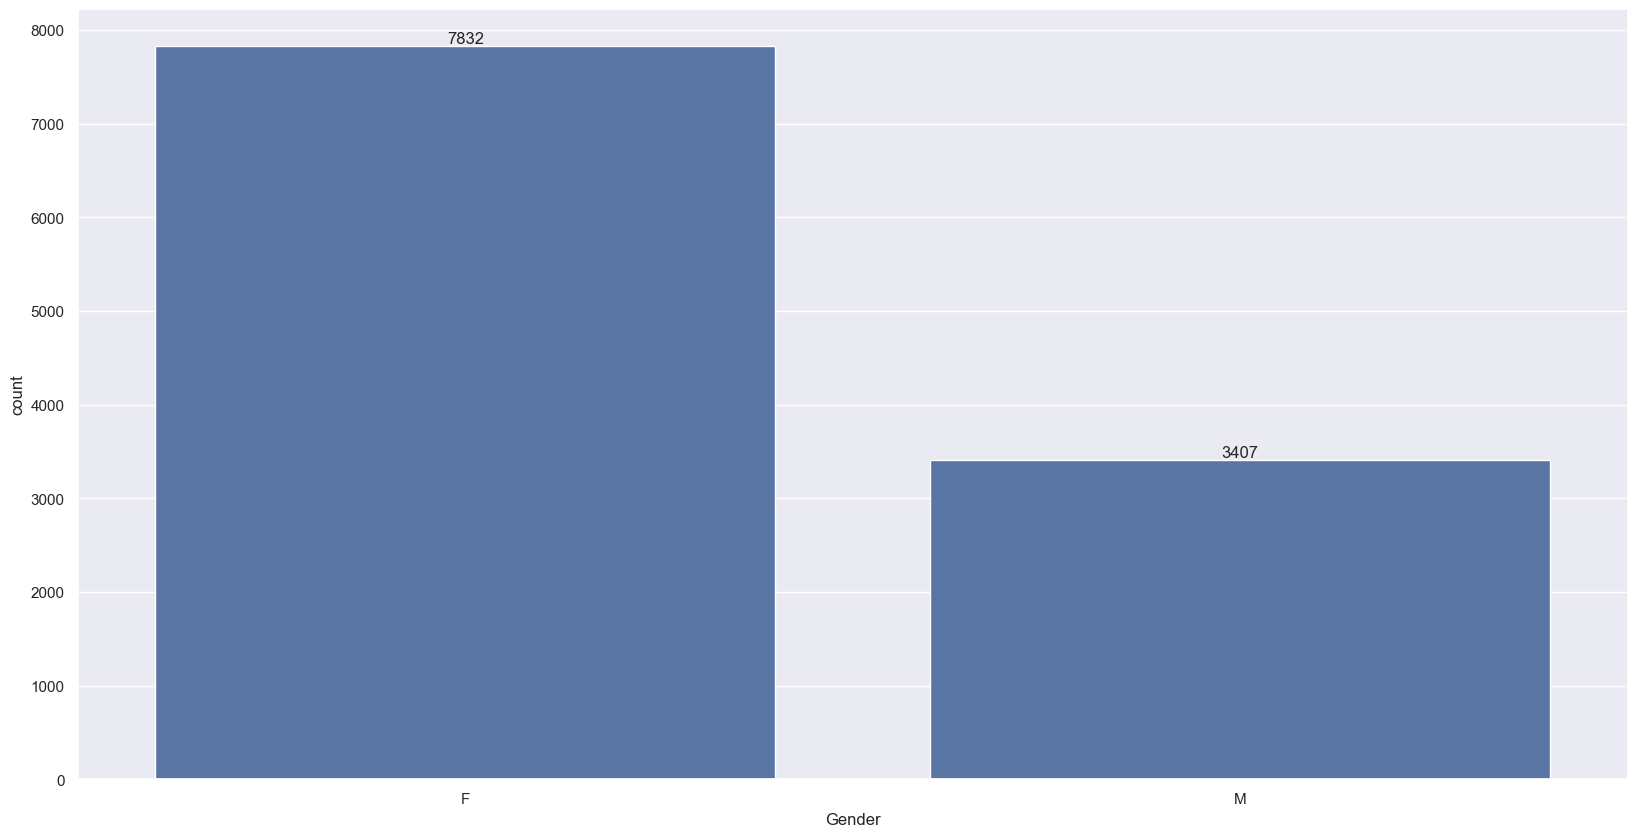

In [29]:
ax = sns.countplot(x='Gender',data=df)
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Gender', ylabel='Amount'>

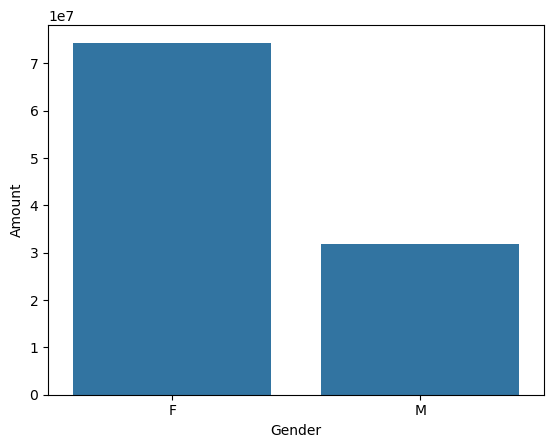

In [18]:
sales_gen = df.groupby(['Gender'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
sns.barplot(x='Gender',y='Amount',data=sales_gen)

**From above graphs we can say that most of buyers are females and purchasing power of females are more than males**

## Age

In [19]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

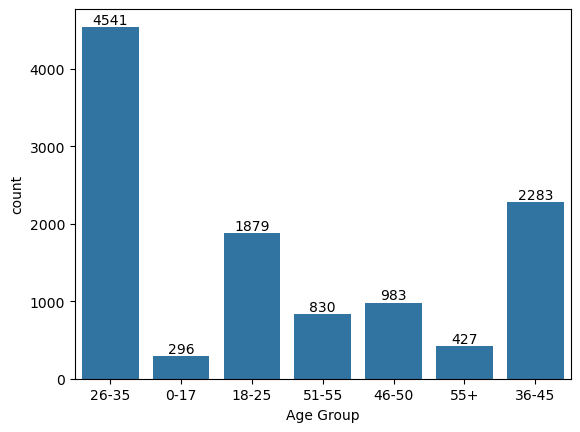

In [20]:
ax =sns.countplot(x='Age Group',data=df)
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Age Group', ylabel='count'>

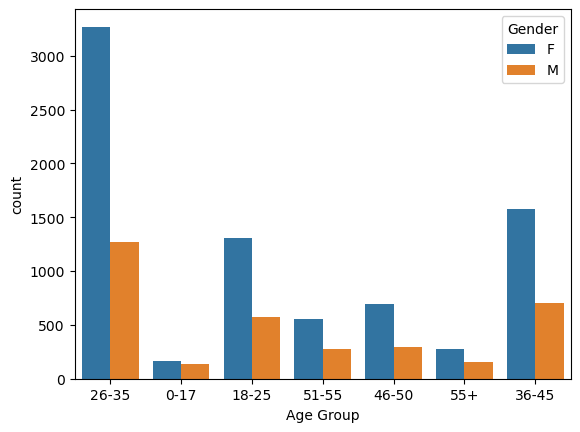

In [21]:
sns.countplot(x='Age Group',hue='Gender',data=df)

<Axes: xlabel='Age Group', ylabel='Amount'>

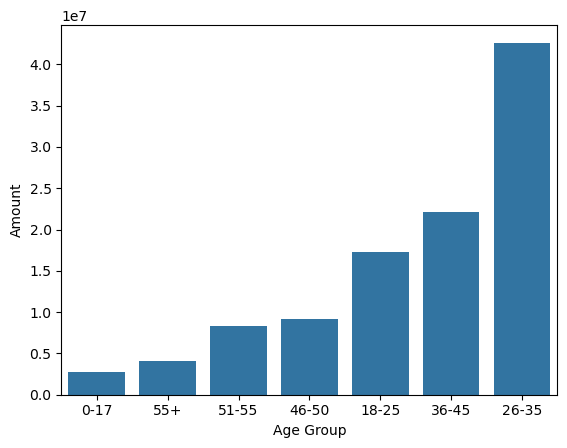

In [22]:
sales_age=df.groupby(['Age Group'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=True)
sns.barplot(x='Age Group',y='Amount',data=sales_age)

**from above graphs we can say that most of buyers are of age group betweem 26-35 years female**

## State


In [23]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

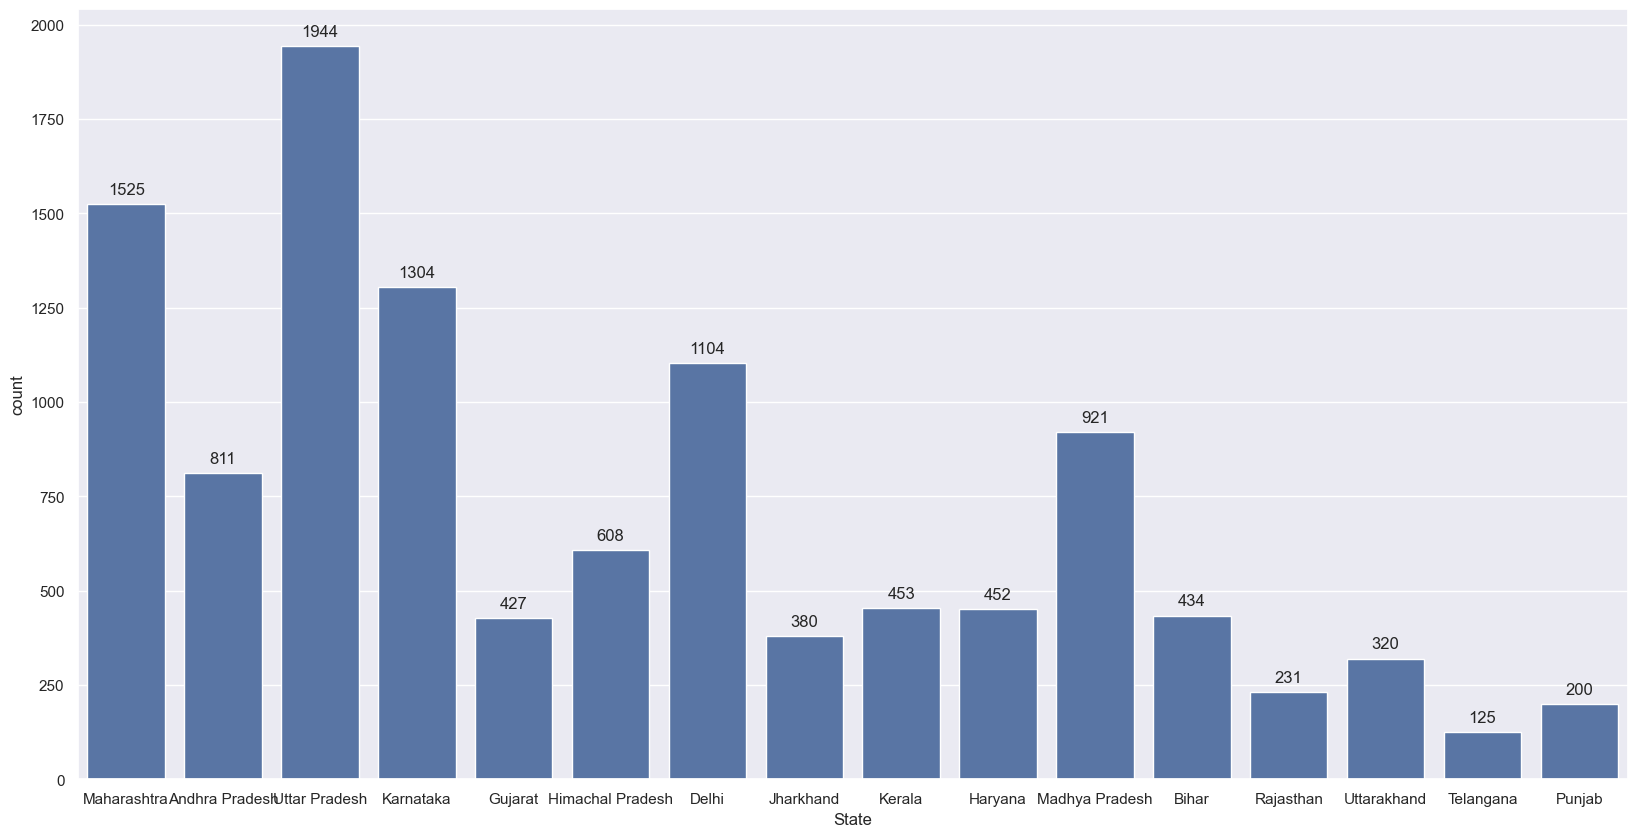

In [30]:
ax =sns.countplot(x='State',data=df)
sns.set(rc=({'figure.figsize':(20,10)}))
for bars in ax.containers:
    ax.bar_label(bars,padding=5)

<Axes: xlabel='State', ylabel='Orders'>

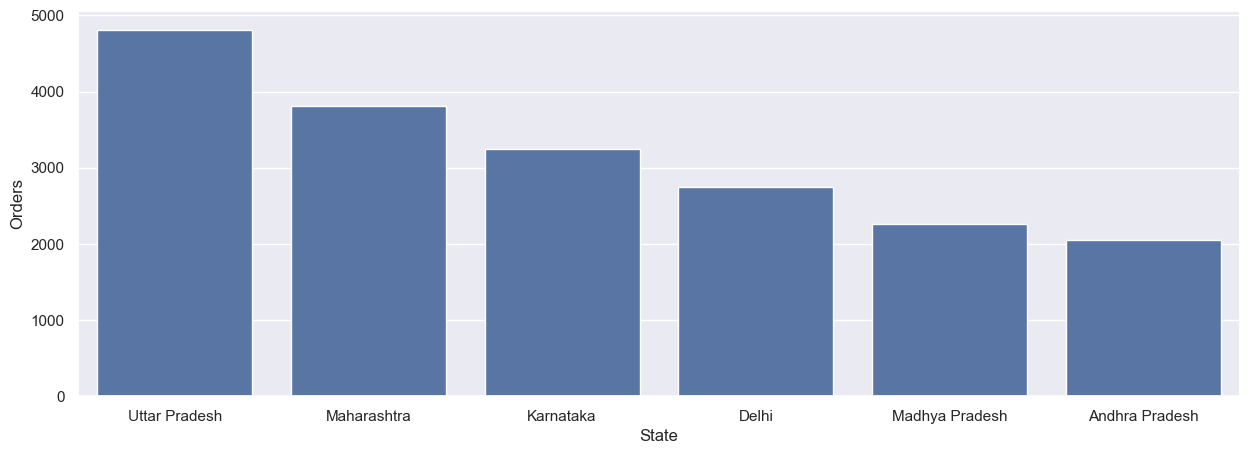

In [24]:
order_states=df.groupby(['State'],as_index=False)['Orders'].sum().sort_values(by='Orders',ascending=False).head(6)
sns.barplot(x='State',y='Orders',data=order_states)

<Axes: xlabel='State', ylabel='Amount'>

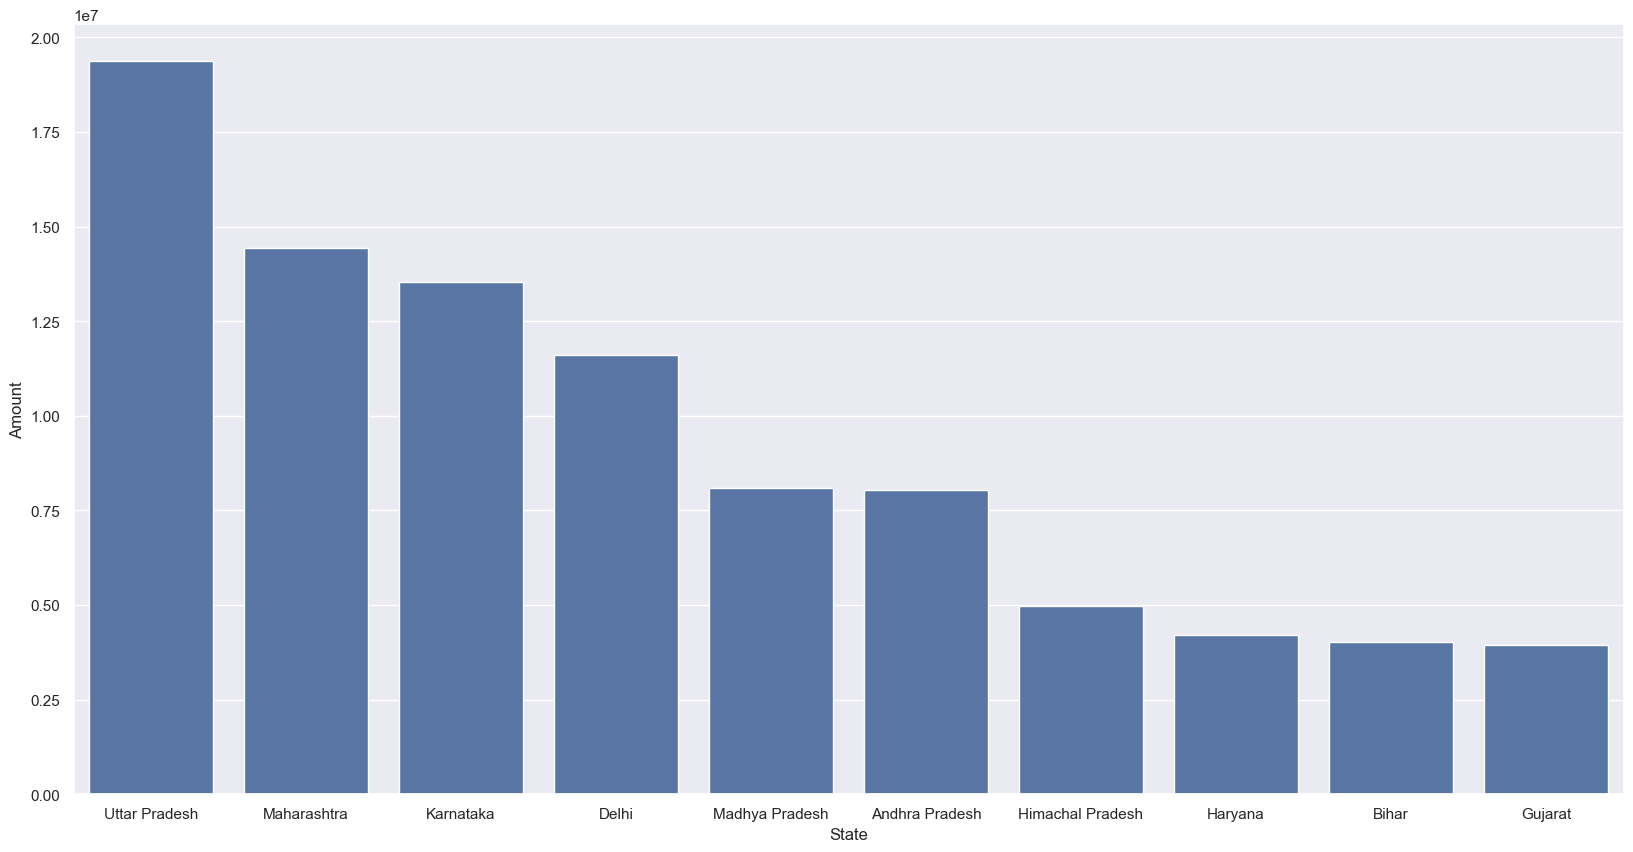

In [32]:
sales_states=df.groupby(['State'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(10)
sns.barplot(x='State',y='Amount',data=sales_states)

**from above graphs we can say that most of orders and sales  from UP and Maharastra**

## Product_Category


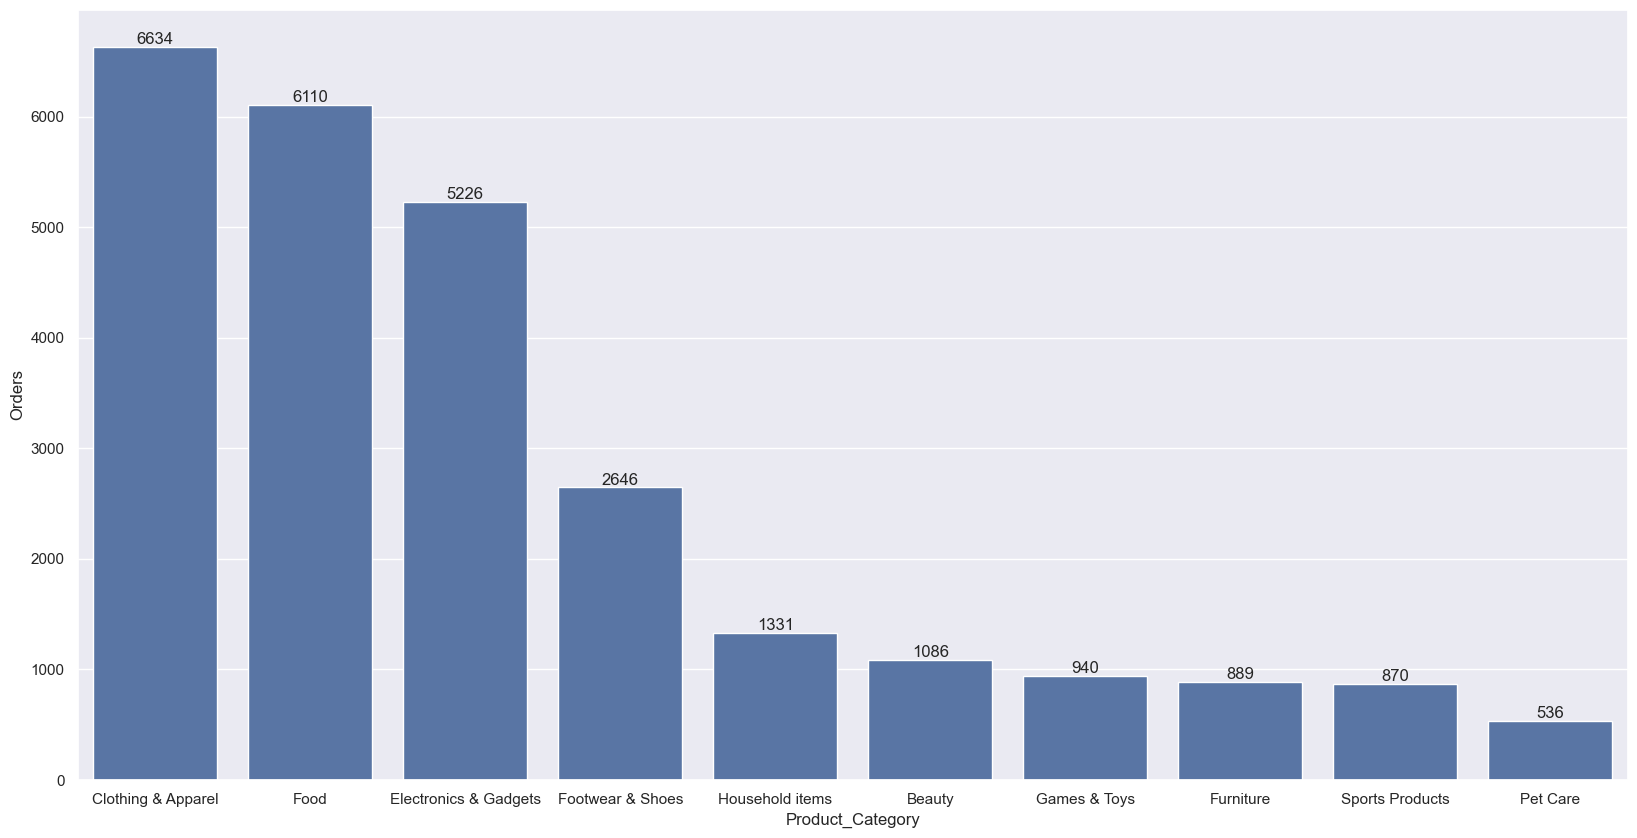

In [44]:
product_category_orders = df.groupby(['Product_Category'],as_index=False)['Orders'].sum().sort_values(by ='Orders',ascending=False).head(10)
ax=sns.barplot(x='Product_Category',y='Orders',data=product_category_orders)
for bars in ax.containers:
    ax.bar_label(bars)

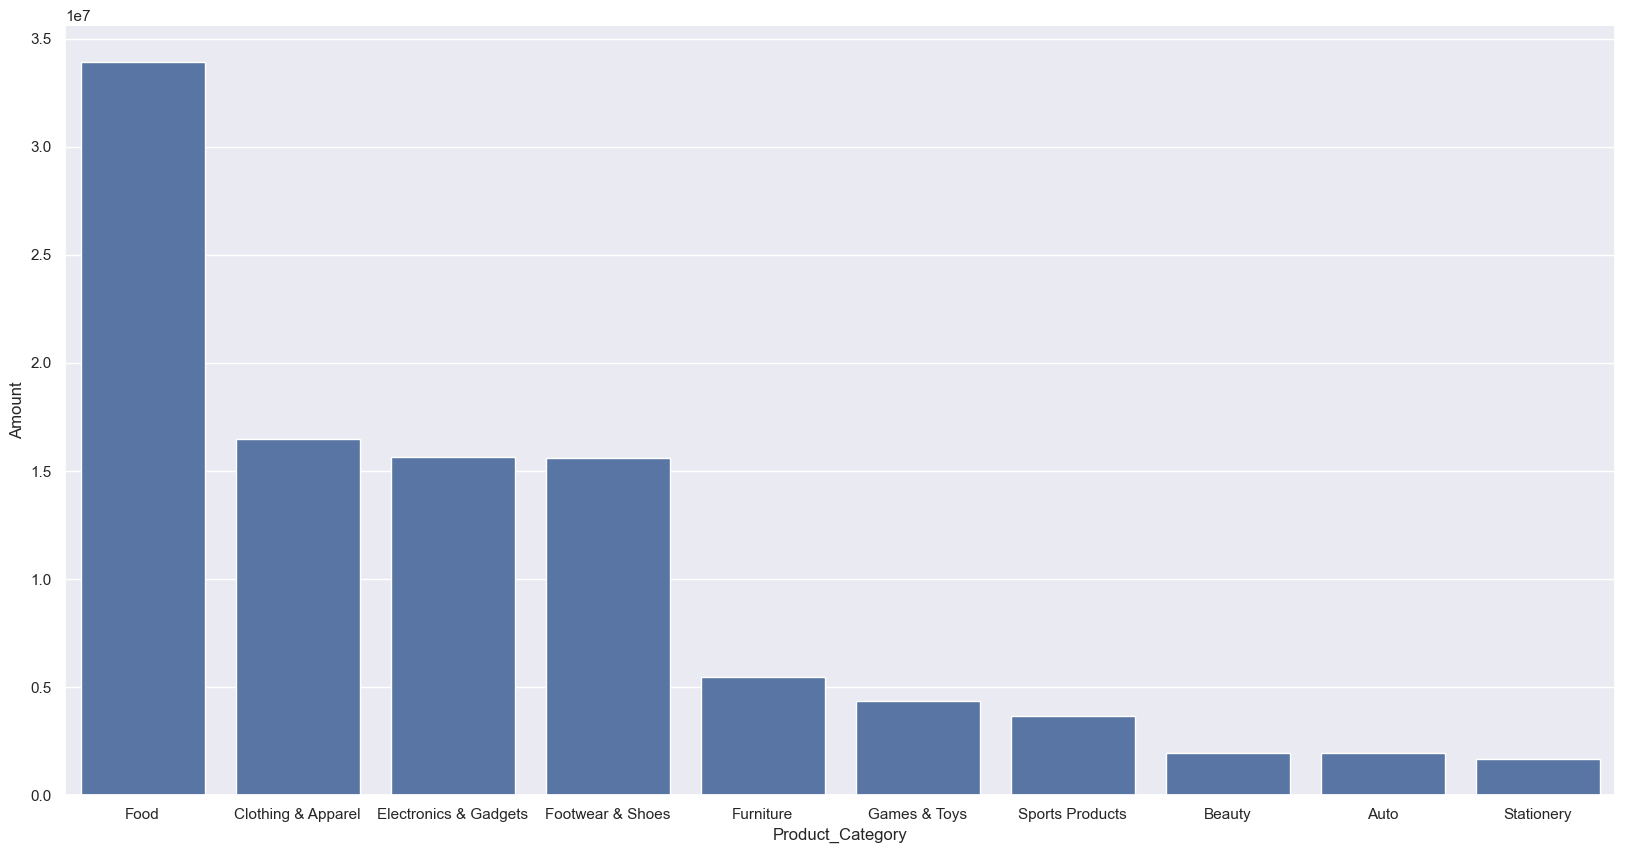

In [47]:
product_category_orders = df.groupby(['Product_Category'],as_index=False)['Amount'].sum().sort_values(by ='Amount',ascending=False).head(10)
ax=sns.barplot(x='Product_Category',y='Amount',data=product_category_orders)



**from above graphs we can say that orders of clothing and apparel are more and total amount spend in food is more than any other catagory**


In [8]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount', 'Status', 'unnamed1'],
      dtype='object')

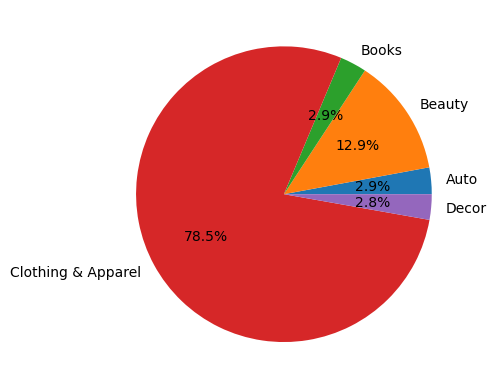

In [30]:
product_catagories =df.groupby('Product_Category')['Orders'].sum().head()
plt.pie(product_catagories,labels=product_catagories.index,autopct='%1.1f%%')
plt.show()

**From the above graph, we can see that Clothing and Apparel has the highest percentage of orders, accounting for 78.5% of the total**

## Marital Status ##


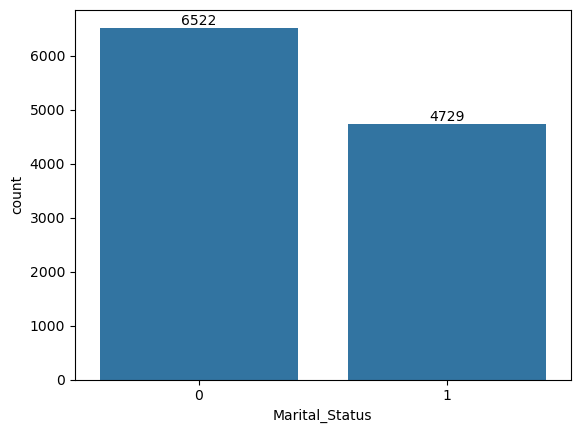

In [33]:
ax = sns.countplot(data = df,x='Marital_Status')
for bars in ax.containers:
    ax.bar_label(bars)
    

<Axes: xlabel='Marital_Status', ylabel='Amount'>

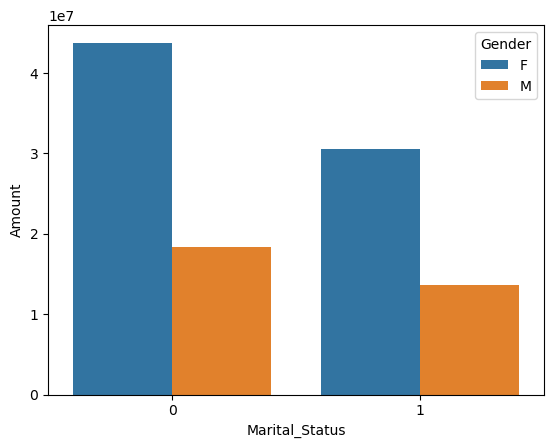

In [4]:
sales_state = df.groupby(['Marital_Status','Gender'], as_index=False)['Amount'].sum()
sales_state = sales_state.sort_values(by='Amount', ascending=False)
sns.barplot(data = sales_state,x = 'Marital_Status',y='Amount',hue = 'Gender')


**from above graphs we can say that most of the buyers are married womens**

## OCCUPATION ##


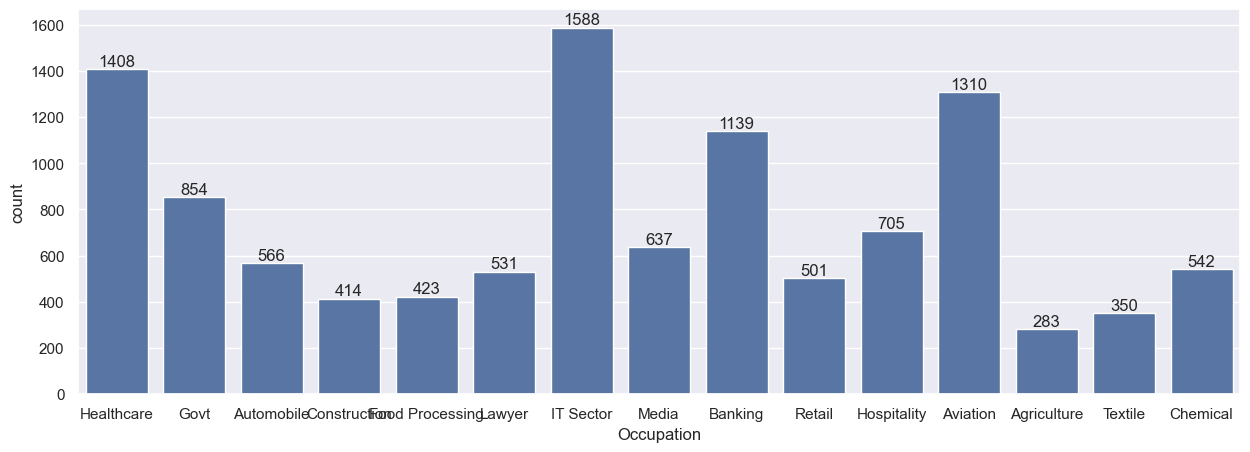

In [10]:
sns.set(rc={'figure.figsize':(15,5)})
ax = sns.countplot(data = df,x ="Occupation")
for bars in ax.containers :
    ax.bar_label(bars)

<Axes: xlabel='Occupation', ylabel='Amount'>

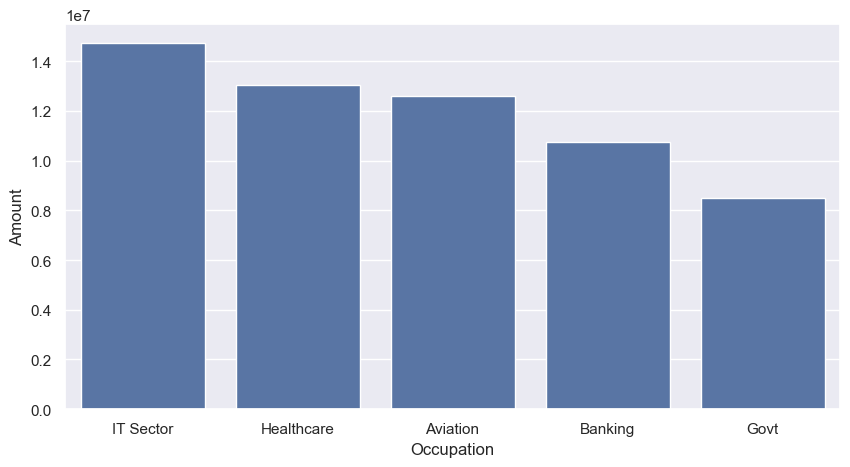

In [20]:
sns.set(rc={'figure.figsize':(10,5)})
sales_state =df.groupby(['Occupation'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False).head()
sns.barplot(data =sales_state,x='Occupation',y='Amount')

**From above graphs we can say that most of buyers are working in IT,Healthcare and Aviation sector**


# Conclusion #

**The Diwali sales were driven mainly by young, married, working women from UP and Maharashtra, with a strong preference for clothing and apparel, while food attracted the highest spending. This highlights the importance of targeting female professionals aged 26–35 in future marketing strategies.**